In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from utils import (
    get_device,
    get_cifar10_datasets,
    GaussianNoiseDataset,
    make_loader,
    CNN,
    load_pretrained_resnet56,
    train_model,
    eval_accuracy,
    build_class_references,
    score_dataset,
    roc_curve_from_scores,
    auc_from_roc,
)


In [2]:

DATA_ROOT = "./data"
CNN_CHECKPOINT_PATH = "./cifar_cnn.pt"

BATCH_SIZE = 128
EPOCHS_CNN = 20 # nb epochs to train the cnn
REF_SAMPLES_PER_CLASS = 500

device = get_device()
print("device =", device)


device = mps


In [3]:
# Datasets et loaders

train_dataset, test_dataset = get_cifar10_datasets(DATA_ROOT)
ood_dataset = GaussianNoiseDataset(len(test_dataset))

train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = make_loader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
ood_loader = make_loader(ood_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("train =", len(train_dataset))
print("test  =", len(test_dataset))
print("ood   =", len(ood_dataset))


train = 50000
test  = 10000
ood   = 10000


In [4]:

def prepare_cnn():
    model = CNN().to(device)

    if os.path.exists(CNN_CHECKPOINT_PATH):
        model.load_state_dict(torch.load(CNN_CHECKPOINT_PATH, map_location=device))
        model.eval()
        print(f"Checkpoint CNN chargé : {CNN_CHECKPOINT_PATH}")
    else:
        print("Aucun checkpoint CNN trouvé. Entraînement du CNN...")
        train_model(model, train_loader, test_loader, epochs=EPOCHS_CNN, device=device)
        torch.save(model.state_dict(), CNN_CHECKPOINT_PATH)
        model.eval()
        print(f"Checkpoint CNN sauvegardé : {CNN_CHECKPOINT_PATH}")

    return model


def run_experiment(name, model, layer_weights, references=None):
    test_acc = eval_accuracy(model, test_loader, device=device)

    if references is None:
        references = build_class_references(
            model=model,
            train_loader=train_loader,
            layer_names=list(layer_weights.keys()),
            max_per_class=REF_SAMPLES_PER_CLASS,
            device=device,
        )

    id_baseline, id_tu = score_dataset(
        model=model,
        data_loader=test_loader,
        references=references,
        layer_weights=layer_weights,
        device=device,
    )

    ood_baseline, ood_tu = score_dataset(
        model=model,
        data_loader=ood_loader,
        references=references,
        layer_weights=layer_weights,
        device=device,
    )

    fpr_baseline, tpr_baseline = roc_curve_from_scores(id_baseline, ood_baseline)
    fpr_tu, tpr_tu = roc_curve_from_scores(id_tu, ood_tu)

    auc_baseline = auc_from_roc(fpr_baseline, tpr_baseline)
    auc_tu = auc_from_roc(fpr_tu, tpr_tu)

    out = {
        "name": name,
        "layer_weights": dict(layer_weights),
        "test_accuracy": float(test_acc),
        "auc_baseline": float(auc_baseline),
        "auc_tu": float(auc_tu),
        "fpr_baseline": fpr_baseline,
        "tpr_baseline": tpr_baseline,
        "fpr_tu": fpr_tu,
        "tpr_tu": tpr_tu,
        "references": references,
    }

    print("-" * 70)
    print(name)
    print("test accuracy :", f"{test_acc:.4f}")
    print("AUC baseline  :", f"{auc_baseline:.4f}")
    print("AUC TU        :", f"{auc_tu:.4f}")
    print("layer_weights :", layer_weights)

    return out


## CNN 

In [5]:

cnn_model = prepare_cnn()

cnn_weights = {"conv1": 1.0, "conv2": 1.0, "conv3": 1.0}

cnn_result = run_experiment(
    name="CNN",
    model=cnn_model,
    layer_weights=cnn_weights,
)


Aucun checkpoint CNN trouvé. Entraînement du CNN...
Epoch 1/20 | train_loss=1.5761 | train_acc=0.4234 | test_acc=0.5234
Epoch 2/20 | train_loss=1.2220 | train_acc=0.5605 | test_acc=0.6012
Epoch 3/20 | train_loss=1.0671 | train_acc=0.6213 | test_acc=0.6405
Epoch 4/20 | train_loss=0.9458 | train_acc=0.6659 | test_acc=0.6726
Epoch 5/20 | train_loss=0.8697 | train_acc=0.6951 | test_acc=0.6872
Epoch 6/20 | train_loss=0.8047 | train_acc=0.7176 | test_acc=0.6947
Epoch 7/20 | train_loss=0.7466 | train_acc=0.7389 | test_acc=0.6911
Epoch 8/20 | train_loss=0.7033 | train_acc=0.7523 | test_acc=0.7119
Epoch 9/20 | train_loss=0.6576 | train_acc=0.7679 | test_acc=0.7257
Epoch 10/20 | train_loss=0.6242 | train_acc=0.7804 | test_acc=0.7261
Epoch 11/20 | train_loss=0.5913 | train_acc=0.7923 | test_acc=0.7208
Epoch 12/20 | train_loss=0.5601 | train_acc=0.8018 | test_acc=0.7321
Epoch 13/20 | train_loss=0.5251 | train_acc=0.8152 | test_acc=0.7229
Epoch 14/20 | train_loss=0.4972 | train_acc=0.8240 | test_ac

## Resnet

In [10]:

resnet56_model = load_pretrained_resnet56(device=device)
print("ResNet56 préentraîné chargé.")

resnet56_all_weights = {"layer1": 1.0, "layer2": 1.0, "layer3": 1.0}

resnet56_references = build_class_references(
    model=resnet56_model,
    train_loader=train_loader,
    layer_names=list(resnet56_all_weights.keys()),
    max_per_class=2000,
    device=device,
)

print("Références ResNet56 construites.")


Using cache found in /Users/rplanchon/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


ResNet56 préentraîné chargé.
Références ResNet56 construites.


In [11]:
resnet56_all_result = run_experiment(
    name="ResNet56 all",
    model=resnet56_model,
    layer_weights={"layer1": 1.0, "layer2": 1.0, "layer3": 1.0},
    references=resnet56_references,
)

resnet56_early_result = run_experiment(
    name="ResNet56 early",
    model=resnet56_model,
    layer_weights={"layer1": 1.0, "layer2": 0.0, "layer3": 0.0},
    references=resnet56_references,
)

resnet56_late_result = run_experiment(
    name="ResNet56 late",
    model=resnet56_model,
    layer_weights={"layer1": 0.0, "layer2": 0.0, "layer3": 1.0},
    references=resnet56_references,
)


----------------------------------------------------------------------
ResNet56 all
test accuracy : 0.9425
AUC baseline  : 0.7690
AUC TU        : 0.5506
layer_weights : {'layer1': 1.0, 'layer2': 1.0, 'layer3': 1.0}
----------------------------------------------------------------------
ResNet56 early
test accuracy : 0.9425
AUC baseline  : 0.7697
AUC TU        : 0.2639
layer_weights : {'layer1': 1.0, 'layer2': 0.0, 'layer3': 0.0}
----------------------------------------------------------------------
ResNet56 late
test accuracy : 0.9425
AUC baseline  : 0.7714
AUC TU        : 0.7245
layer_weights : {'layer1': 0.0, 'layer2': 0.0, 'layer3': 1.0}


In [12]:

results = [
    cnn_result,
    resnet56_all_result,
    resnet56_early_result,
    resnet56_late_result,
]

print(f"{'expérience':<18} {'acc':>8} {'auc baseline':>14} {'auc tu':>10}")
print("-" * 54)
for r in results:
    print(f"{r['name']:<18} {r['test_accuracy']:>8.4f} {r['auc_baseline']:>14.4f} {r['auc_tu']:>10.4f}")


expérience              acc   auc baseline     auc tu
------------------------------------------------------
CNN                  0.7141         0.8238     1.0000
ResNet56 all         0.9425         0.7690     0.5506
ResNet56 early       0.9425         0.7697     0.2639
ResNet56 late        0.9425         0.7714     0.7245


## ROC curves for each experiment

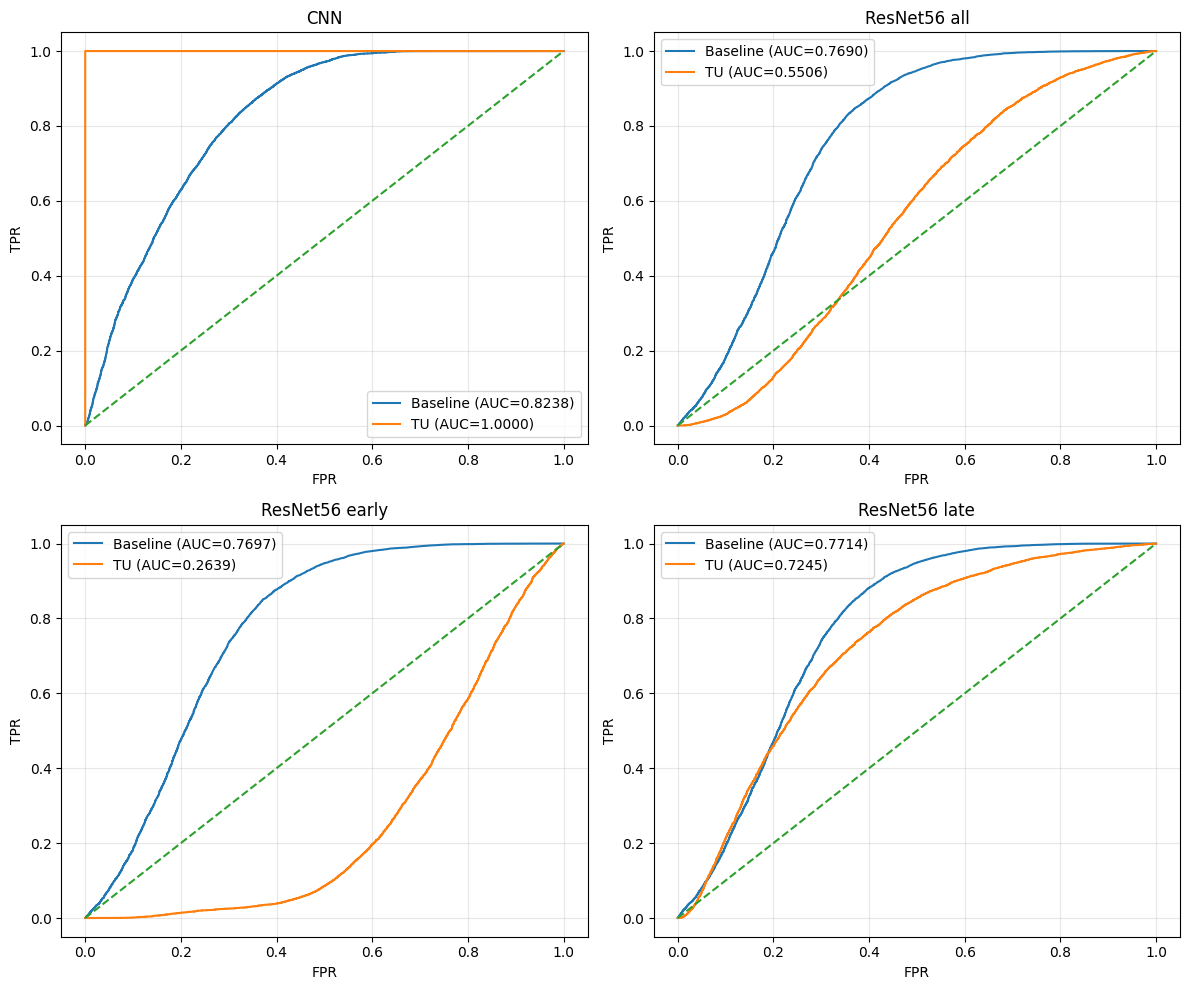

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, r in zip(axes, results):
    ax.plot(r["fpr_baseline"], r["tpr_baseline"], label=f"Baseline (AUC={r['auc_baseline']:.4f})")
    ax.plot(r["fpr_tu"], r["tpr_tu"], label=f"TU (AUC={r['auc_tu']:.4f})")
    ax.plot([0, 1], [0, 1], "--")
    ax.set_title(r["name"])
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
